# Downloading, tailoring, plotting and animating data from EUMETSAT using the Data Access Catalog

Use EUMDAC's Python library to download from EUMETSAT Data Store
User Guide : 
https://user.eumetsat.int/resources/user-guides/eumetsat-data-access-client-eumdac-guide

## Initialize token

In [1]:
# Written by Lucie Reymondet, UCSD Scripps Institution of Oceanography
# Code to download EUMETSAT data using the EUMETSAT Data Access Client (EUMDAC) Python library and Data Tailor

import eumdac
import datetime
import shutil
import time
import fnmatch
import requests
from IPython.core.display import HTML
import time
import os
import zipfile
import json
import xarray as xr

# Insert personal key and secret
consumer_key = '2WA_GJftbSnmegkQ6gNBxSqo_Foa'
consumer_secret = 'khEoQY_BjsQD1QDZ83ntHE9gIBoa'

# Generate token, by default validity = 24h
credentials = (consumer_key, consumer_secret)
token = eumdac.AccessToken(credentials)
try:
    print(f"This token '{token}' expires {token.expiration}")
except requests.exceptions.HTTPError as error:
    print(f"Error when tryng the request to the server: '{error}'")

# Initialize DataStore and DataTailor instances
datastore = eumdac.DataStore(token)
datatailor = eumdac.DataTailor(token)


This token '7c3a31cb-d4f9-398e-bab1-3dfe9ee1ea66' expires 2025-12-23 09:11:40.684193


## Check available products inside a collection

In [8]:
# Select and filter a collection

# Desired collection
# coll = 'EO:EUM:DAT:0665' # MTG FCI HR
coll = 'EO:EUM:DAT:0662' # MTG FCI NR
# coll = 'EO:EUM:DAT:0678' # MTG FCI cloud mask
# coll = 'EO:EUM:DAT:MSG:HRSEVIRI' # MSG SEVIRI
# coll = 'EO:EUM:DAT:MSG:CLM' # MSG SEVIRI

# Display search options for the selected collection
try:
    selected_collection = datastore.get_collection(coll) 
    print(f"{selected_collection} - {selected_collection.title}")
    print(f"Description: {selected_collection.abstract}")
    print(f"Metadata: {selected_collection.metadata}")
    print(f"Search options: {selected_collection.search_options} \n")
except eumdac.datastore.DataStoreError as error:
    print(f"Error related to the data store: '{error}'")
except eumdac.collection.CollectionError as error:
    print(f"Error related to the collection: '{error}'")
except requests.exceptions.ConnectionError as error:
    print(f"Error related to the connection: '{error}'")
except requests.exceptions.RequestException as error:
    print(f"Unexpected error: {error}")

# Filter criteria
bounding_box = '11, -41, 21, -31' #(W, S, E, N) 
start = datetime.datetime(2025, 1, 1, 12, 0)
end = datetime.datetime(2025, 1, 1, 12, 10)
# satellite = 'MTI1' # For HRSEVIRI: 'MSGn' where n=1,2,3,4, For FCI: 'MTIn' where n=1,2,3,4 (only MTI1 operational as of Nov 2025)

# Retrieve and display products that match our filter
products = selected_collection.search(
    # geo='POLYGON(({}))'.format(','.join(["{} {}".format(*coord) for coord in geometry])),
    # bbox=bounding_box,
    dtstart=start, dtend=end,
    # sat=satellite
    )
try:
    print(f'{products.total_results} products found for the given filters:')
    for product in products:
        print(product)
except eumdac.collection.CollectionError as error:
    print(f"Error related to the collection: '{error}'")
except requests.exceptions.ConnectionError as error:
    print(f"Error related to the connection: '{error}'")
except requests.exceptions.RequestException as error:
    print(f"Unexpected error: {error}")

EO:EUM:DAT:0662 - FCI Level 1c Normal Resolution Image Data - MTG - 0 degree
Description: The rectified (Level 1c) Meteosat FCI full disc image data in normal spatial (FDHSI) resolution. The FCI instrument consists of 16 imaging spectral channels ranging from 0.4 µm to 13.3 µm with the channel at 3.8 µm having an extended dynamic range dedicated to fire monitoring. The spatial resolution is 1km for visible and near-infrared channels and 2 km for infrared channels. FCI Level 1c rectified radiance dataset consists of a set of files that contain the level 1c science data rectified to a reference grid together with the auxiliary data associated with the processing configuration and the quality assessment of the dataset.
Metadata: {'geometry': {'type': 'Polygon', 'coordinates': [[[-79, 79], [-79, -79], [79, -79], [79, 79], [-79, 79]]]}, 'properties': {'type': 'Properties', 'kind': 'Dataset', 'identifier': 'EO:EUM:DAT:0662', 'title': 'FCI Level 1c Normal Resolution Image Data - MTG - 0 degre

## Download products

Products can be downloaded by providing either their product ID, or a combination of their collection ID and several search parameters. We can download all products resulting from the above search, or a single products. We can also download entire products or specific file components (e.g. metadata only), or chunks based on geographical coverage.

In [9]:
# Option 1 : Download all products resulting from the filtered search

for product in products:
    try:
        with product.open() as fsrc, open(fsrc.name, mode='wb') as fdst:
            shutil.copyfileobj(fsrc, fdst)
            print(f'Download of product {product} finished.')
    except eumdac.product.ProductError as error:
        print(f"Error related to the product '{product}' while trying to download it: '{error.msg}'")
    except requests.exceptions.ConnectionError as error:
        print(f"Error related to the connection: '{error}'")
    except requests.exceptions.RequestException as error:
        print(f"Unexpected error: {error}")
    
print('All downloads are finished.')

Download of product W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250101120300_IDPFI_OPE_20250101120007_20250101120924_N__O_0073_0000 finished.
All downloads are finished.


In [ ]:
# Option 2 : Download a single product
if coll=='EO:EUM:DAT:MSG:HRSEVIRI':
    single_product = datastore.get_product(
        product_id='MSG3-SEVI-MSG15-0100-NA-20230330121241.373000000Z-NA',
        collection_id='EO:EUM:DAT:MSG:HRSEVIRI')
elif coll=='EO:EUM:DAT:MSG:CLM':
    single_product = datastore.get_product(
        product_id='',
        collection_id='EO:EUM:DAT:MSG:CLM')
else:
    raise ValueError(f"Unknown collection")

with single_product.open() as fsrc, open(fsrc.name, mode='wb') as fdst:
    print(fsrc.name)
    shutil.copyfileobj(fsrc, fdst)


MSG3-SEVI-MSG15-0100-NA-20230330121241.373000000Z-NA.zip


In [ ]:
# Option 3 : Download chunks of the products based on coverage

FD = ["*_????_00[0-3][0-9].nc", "*_????_0040.nc", "*_????_0041.nc"] # Full disc; chunks 01-40 + 41
H1 = ["*_????_000[1-9].nc", "*_????_001[0-9].nc", "*_????_002[0-1].nc", "*_????_0041.nc"] # chunks 01-21 + 41
H2 = ["*_????_002[0-9].nc", "*_????_003[0-9].nc", "*_????_0040.nc", "*_????_0041.nc"] # chunks 20-40 + 41
T1 = ["*_????_000[1-9].nc", "*_????_001[0-6].nc", "*_????_0041.nc"] # chunks 01-16 + 41
T2 = ["*_????_001[3-9].nc", "*_????_002[0-7].nc", "*_????_0041.nc"] # chunks 13-27 + 41
T3 = ["*_????_002[6-9].nc", "*_????_003[0-9].nc", "*_????_0040.nc", "*_????_0041.nc"] # chunks 26-48 + 41
Q1 = ["*_????_000[0-9].nc", "*_????_001[0-3].nc", "*_????_0041.nc"] # chunks 01-13 + 41
Q2 = ["*_????_001[0-9].nc", "*_????_002[0-1].nc", "*_????_0041.nc"] # chunks 10-21 + 41
Q3 = ["*_????_002[0-9].nc", "*_????_0030.nc", "*_????_0041.nc"] # chunks 20-30 + 41
Q4 = ["*_????_0029.nc", "*_????_003[0-9].nc", "*_????_0040.nc", "*_????_0041.nc"] # chunks 29-40 + 41

# This function checks if a product entry is part of the requested coverage
def get_coverage(coverage, filenames):
    chunks = []
    for pattern in coverage:
        for file in filenames:
            if fnmatch.fnmatch(file, pattern):
                chunks.append(file)
    return chunks

# Select the coverage area
coverage = Q1  # Change this to the desired coverage

for product in products:
    # Get the matching files
    matching_files = get_coverage(coverage, product.entries)

    if not matching_files:
        print("No matching files found for the selected coverage.")
    else:
        for file in matching_files:
            try:
                with product.open(entry=file) as fsrc, open(fsrc.name, mode='wb') as fdst: # filter by entry = ...
                    shutil.copyfileobj(fsrc, fdst)
                    print(f'Download of file {fsrc.name} finished.')
            except Exception as e:
                print(f"Error downloading {file}: {e}")

## Customise products using Data Tailor

The Data Tailor is a product customisation toolbox designed to enable users to tailor satellite data to their specific needs. It offers the ability to subset and aggregate data products across space and time, filter layers, generate quick looks, reproject data onto new coordinate reference systems, and reformat data into widely used Geographic Information System (GIS) formats such as netCDF and GeoTIFF, as well as image formats like JPEG and PNG. The Data Tailor can currently customize data from various satellite collections, including MTG FCI and MSG SEVIRI.
After the customisation is DONE, you can download the customised product from the Data Tailor Web Services

In [ ]:
# Define the chain configuration
if coll=='EO:EUM:DAT:MSG:HRSEVIRI':
    chain = eumdac.tailor_models.Chain(
        product='HRSEVIRI',
        format='netcdf4',
        filter={"bands": ['channel_9']},
        projection='geographic',
        roi={"NSWE": [-31,-41,11,21]},
    )
elif coll=='EO:EUM:DAT:MSG:CLM':
    chain = eumdac.tailor_models.Chain(
        product='MSGCLMK',
        format='netcdf4',
        filter={"bands": ['cloud_mask']},
        projection='geographic',
        roi={"NSWE": [-31,-41,11,21]},
    )
else:
    raise ValueError(f"Unknown collection")

for product in products:
    # Send the customisation to Data Tailor Web Services
    customisation = datatailor.new_customisation(product, chain=chain)

    status = customisation.status
    sleep_time = 20 # seconds
    
    # Loop to read current status of the customisation
    print("Starting customisation process...")
    while status:
        status = customisation.status
        if "DONE" in status:
            print(f"Customisation {customisation._id} is successfully completed.")
            print(f"Downloading the output of the customisation {customisation._id}")
            cust_file = fnmatch.filter(customisation.outputs, '*')[0]
            print(cust_file)
            with customisation.stream_output(cust_file) as stream, open(stream.name, mode='wb') as fdst:
                shutil.copyfileobj(stream, fdst)
            print(f"Download finished for customisation {customisation._id}.")
            break
        elif status in ["ERROR", "FAILED", "DELETED", "KILLED", "INACTIVE"]:
            print(f"Customisation {customisation._id} was unsuccessful. Customisation log is printed.\n")
            print(customisation.logfile)
            break
        elif "QUEUED" in status:
            print(f"Customisation {customisation._id} is queued.")
        elif "RUNNING" in status:
            print(f"Customisation {customisation._id} is running.")
        time.sleep(sleep_time)


In [2]:
import xarray as xr
import os
import glob
import re
import pandas as pd
import numpy as np

dirin = ""

def load_and_concat(pattern_str, prefix, dirin):
    """Load EUMETSAT files, normalize time (seconds → 0), and concatenate."""
    pattern = re.compile(pattern_str)
    files = sorted(glob.glob(os.path.join(dirin, f"{prefix}_*.nc")))
    if not files:
        raise FileNotFoundError(f"No matching files found for {prefix} in {dirin}")

    times = []
    for f in files:
        basename = os.path.basename(f)
        match = pattern.search(basename)
        if not match:
            raise ValueError(f"Could not extract start time from filename: {basename}")
        timestamp_str = match.group(1)
        timestamp = pd.to_datetime(timestamp_str, format="%Y%m%dT%H%M%S")
        # Normalize: seconds → 0
        timestamp = timestamp.floor("min").replace(second=0)
        times.append(timestamp)

    datasets = [xr.open_dataset(f) for f in files]
    combined = xr.concat(datasets, dim=xr.Variable("time", times))
    return combined


# --- Load both products and combine snapshots along time dimension
IR = load_and_concat(r"HRSEVIRI_(\d{8}T\d{6})Z", "HRSEVIRI", dirin)
# CLM = load_and_concat(r"_(\d{8}T\d{6})Z", "", dirin)

# --- Extract relevant variables ---
IRrad = IR["channel_9"]
# CLMstate = CLM["cloud_state"]

# --- Keep only timestamps common to both ---
# common_times = np.intersect1d(IRrad["time"].values, CLMstate["time"].values)

# IRrad = IRrad.sel(time=common_times)
# CLMstate = CLMstate.sel(time=common_times)

# --- Save result ---
IRrad.to_netcdf("HRSEVIRI.nc")
# CLMstate.to_netcdf("FCIL2CLM.nc")

# print(f"Common timestamps count: {len(common_times)}")


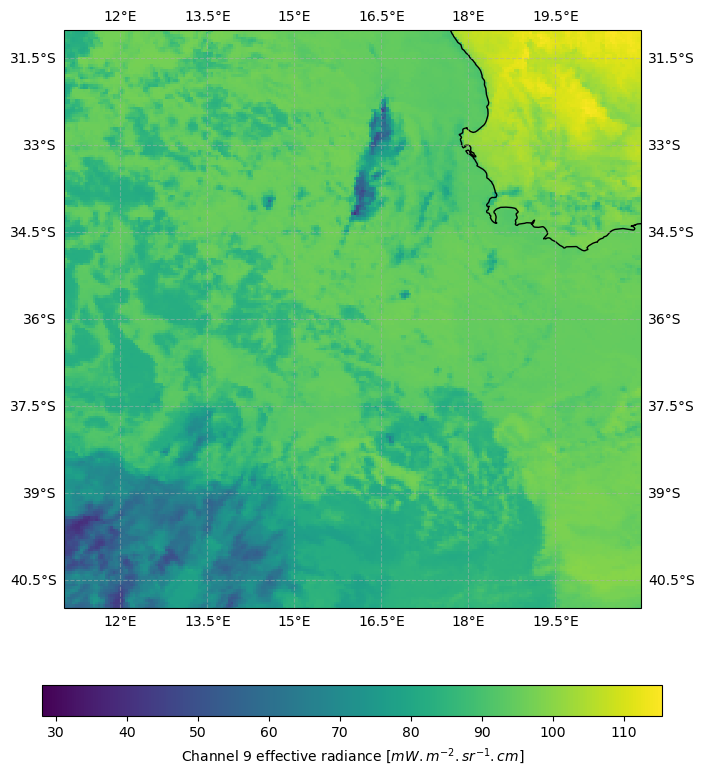

In [5]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
import numpy as np
from pandas import to_datetime


IR=xr.open_dataset("HRSEVIRI.nc")['channel_9']
# CLM=xr.open_dataset("FCIL2CLM.nc")['cloud_state']

lat, lon = IR.lat.values, IR.lon.values
Lat, Lon = np.meshgrid(lon,lat)
times = IR.time.values

# CLM = xr.where(CLM>1.1,1,0)
# CLM_interp = CLM.interp(lat=lat,lon=lon,method='linear')

vmin = IR.min().item()
vmax = IR.max().item()

# CLM_interp = CLM_interp.where(CLM_interp>=1)
# alpha = CLM_interp.clip(0,1).fillna(0)

fig, ax = plt.subplots(figsize=(10,10), dpi=100, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8, alpha=0.5,linestyle='--')

ir = ax.pcolormesh(Lat, Lon, IR.isel(time=0).data,
                   vmin=vmin, vmax=vmax)
# clm = ax.pcolormesh(Lat, Lon, np.ones_like(IR.isel(time=0).data), 
#                     alpha=alpha.isel(time=0).data,color='white',shading='auto',zorder=10)

cb = plt.colorbar(ir,ax=ax,orientation='horizontal',pad=0.1,shrink=0.8)
cb.set_label(r"Channel 9 effective radiance [$mW.m^{-2}.sr^{-1}.cm$]")

plt.tight_layout

def update(frame):
    ir.set_array(IR.isel(time=frame).data)
    # clm.set_alpha(alpha.isel(time=frame).data)
    return ir
ani = FuncAnimation(fig, update, frames=len(times), blit=False)

ani.save(
    f'HRSEVIRI{to_datetime(times[0]).strftime("%Y%m%d_%H%M")}-'
    f'{to_datetime(times[-1]).strftime("%Y%m%d_%H%M")}.mp4',
    writer='ffmpeg',
    fps=2,
    bitrate=10000
)